In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [15]:
import pandas as pd
import os

# Get the correct absolute path
base_path = os.path.abspath("data/liar_dataset")
print("Looking in:", base_path)  # confirm the path first

columns = [
    "id", "label", "statement", "subject",
    "speaker", "job_title", "state_info",
    "party_affiliation", "barely_true_count",
    "false_count", "half_true_count",
    "mostly_true_count", "pants_on_fire_count",
    "context"
]

train_df = pd.read_csv(f"{base_path}/train.tsv", sep="\t", header=None, names=columns)
valid_df = pd.read_csv(f"{base_path}/valid.tsv", sep="\t", header=None, names=columns)
test_df  = pd.read_csv(f"{base_path}/test.tsv",  sep="\t", header=None, names=columns)

print("Train size:", len(train_df))
print("Valid size:", len(valid_df))
print("Test size: ", len(test_df))

Looking in: c:\Users\Santosh\OneDrive\Desktop\Project 1\data\liar_dataset
Train size: 10240
Valid size: 1284
Test size:  1267


In [16]:
train_df[["statement", "speaker", "label"]].head()

,statement,speaker,label
0,Says the Annies List political group supports ...,dwayne-bohac,false
1,When did the decline of coal start? It started...,scott-surovell,half-true
2,"Hillary Clinton agrees with John McCain ""by vo...",barack-obama,mostly-true
3,Health care reform legislation is likely to ma...,blog-posting,false
4,The economic turnaround started at the end of ...,charlie-crist,half-true


In [17]:
fake_labels = ["false", "barely-true", "pants-fire"]
real_labels = ["true", "mostly-true", "half-true"]

def convert_label(label):
    if label in fake_labels:
        return "fake"
    elif label in real_labels:
        return "real"
    else:
        return None

train_df["binary_label"] = train_df["label"].apply(convert_label)
valid_df["binary_label"] = valid_df["label"].apply(convert_label)
test_df["binary_label"]  = test_df["label"].apply(convert_label)

# Drop nulls
train_df = train_df.dropna(subset=["binary_label"])
valid_df = valid_df.dropna(subset=["binary_label"])
test_df  = test_df.dropna(subset=["binary_label"])

print(train_df["binary_label"].value_counts())

binary_label
real    5752
fake    4488
Name: count, dtype: int64


In [18]:
print(train_df.isnull().sum())

id                        0
label                     0
statement                 0
subject                   2
speaker                   2
job_title              2898
state_info             2210
party_affiliation         2
barely_true_count         2
false_count               2
half_true_count           2
mostly_true_count         2
pants_on_fire_count       2
context                 102
binary_label              0
dtype: int64


C:\Users\Santosh\AppData\Local\Temp\ipykernel_2128\1763269637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="binary_label", data=train_df, palette=["#E24B4A", "#1D9E75"])


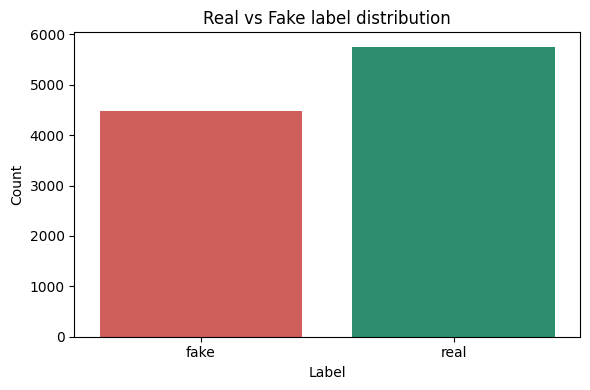

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x="binary_label", data=train_df, palette=["#E24B4A", "#1D9E75"])
plt.title("Real vs Fake label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [20]:
train_df.to_csv("data/liar_dataset/train_clean.csv", index=False)
valid_df.to_csv("data/liar_dataset/valid_clean.csv", index=False)
test_df.to_csv("data/liar_dataset/test_clean.csv",   index=False)

print("Cleaned data saved!")

Cleaned data saved!


day3Text Cleaning & Visualizations

In [21]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Santosh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [22]:
train_df = pd.read_csv("data/liar_dataset/train_clean.csv")
valid_df = pd.read_csv("data/liar_dataset/valid_clean.csv")
test_df  = pd.read_csv("data/liar_dataset/test_clean.csv")

print("Loaded successfully!")
print(train_df.shape)

Loaded successfully!
(10240, 15)


In [23]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

train_df["clean_statement"] = train_df["statement"].apply(clean_text)

print("Before:", train_df["statement"][0])
print("After :", train_df["clean_statement"][0])

Before: Says the Annies List political group supports third-trimester abortions on demand.
After : says annies list political group supports thirdtrimester abortions demand


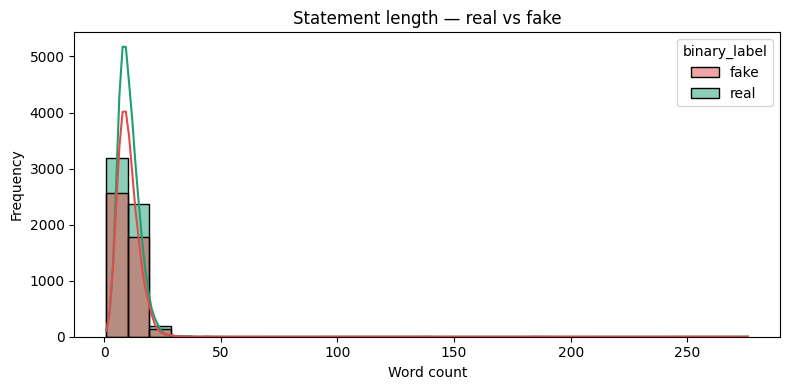

In [24]:
train_df["word_count"] = train_df["clean_statement"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(data=train_df, x="word_count", hue="binary_label",
             palette=["#E24B4A", "#1D9E75"], bins=30, kde=True)
plt.title("Statement length — real vs fake")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

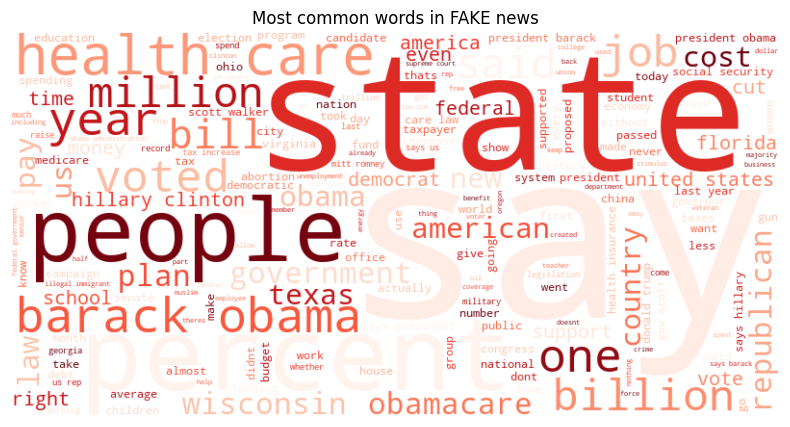

In [25]:
fake_text = " ".join(train_df[train_df["binary_label"] == "fake"]["clean_statement"])

wc = WordCloud(width=800, height=400,
               background_color="white",
               colormap="Reds").generate(fake_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most common words in FAKE news")
plt.show()

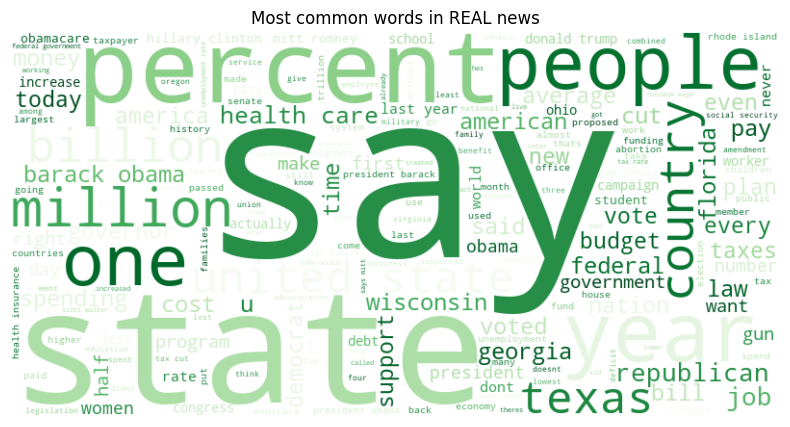

In [26]:
real_text = " ".join(train_df[train_df["binary_label"] == "real"]["clean_statement"])

wc = WordCloud(width=800, height=400,
               background_color="white",
               colormap="Greens").generate(real_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most common words in REAL news")
plt.show()

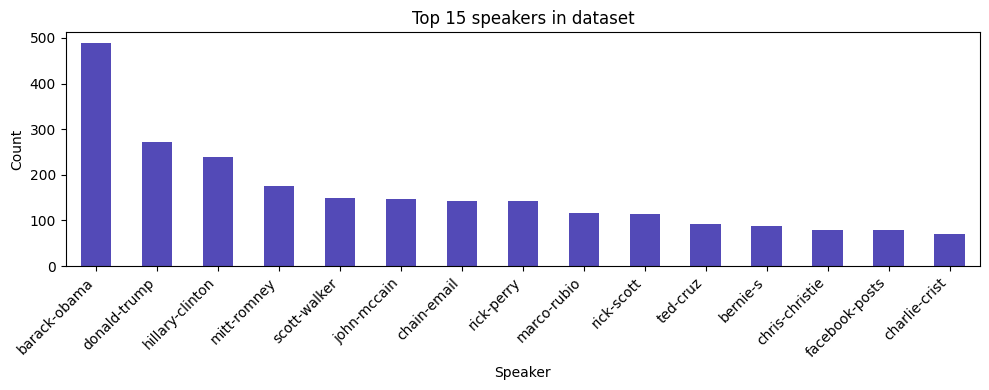

In [27]:
plt.figure(figsize=(10, 4))
train_df["speaker"].value_counts().head(15).plot(kind="bar", color="#534AB7")
plt.title("Top 15 speakers in dataset")
plt.xlabel("Speaker")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [28]:
train_df.to_csv("data/liar_dataset/train_clean.csv", index=False)
print("Saved with clean_statement and word_count columns!")

Saved with clean_statement and word_count columns!


Day 4 — Text Preprocessing Pipeline

In [30]:
import sys
sys.path.append("src")

from data_utils import load_data, preprocess

train_df, valid_df, test_df = load_data(
    "data/liar_dataset/train.tsv",
    "data/liar_dataset/valid.tsv",
    "data/liar_dataset/test.tsv"
)

train_df = preprocess(train_df)
valid_df = preprocess(valid_df)
test_df  = preprocess(test_df)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test: ", test_df.shape)
print(train_df[["statement", "clean_statement", "binary_label"]].head(3))

Train: (10240, 17)
Valid: (1284, 17)
Test:  (1267, 17)
                                           statement  \
0  Says the Annies List political group supports ...   
1  When did the decline of coal start? It started...   
2  Hillary Clinton agrees with John McCain "by vo...   

                                     clean_statement binary_label  
0  says annies list political group supports thir...         fake  
1  decline coal start started natural gas took st...         real  
2  hillary clinton agrees john mccain voting give...         real  


In [32]:
import sys
sys.path.append("src")

from data_utils import load_data, preprocess

train_df, valid_df, test_df = load_data(
    "data/liar_dataset/train.tsv",
    "data/liar_dataset/valid.tsv",
    "data/liar_dataset/test.tsv"
)

train_df = preprocess(train_df)
valid_df = preprocess(valid_df)
test_df  = preprocess(test_df)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test: ", test_df.shape)
print(train_df[["statement", "clean_statement", "binary_label"]].head(3))

Train: (10240, 17)
Valid: (1284, 17)
Test:  (1267, 17)
                                           statement  \
0  Says the Annies List political group supports ...   
1  When did the decline of coal start? It started...   
2  Hillary Clinton agrees with John McCain "by vo...   

                                     clean_statement binary_label  
0  says annies list political group supports thir...         fake  
1  decline coal start started natural gas took st...         real  
2  hillary clinton agrees john mccain voting give...         real  


In [33]:
from data_utils import save_data

save_data(train_df, "data/liar_dataset/train_clean.csv")
save_data(valid_df, "data/liar_dataset/valid_clean.csv")
save_data(test_df,  "data/liar_dataset/test_clean.csv")

Saved: data/liar_dataset/train_clean.csv
Saved: data/liar_dataset/valid_clean.csv
Saved: data/liar_dataset/test_clean.csv


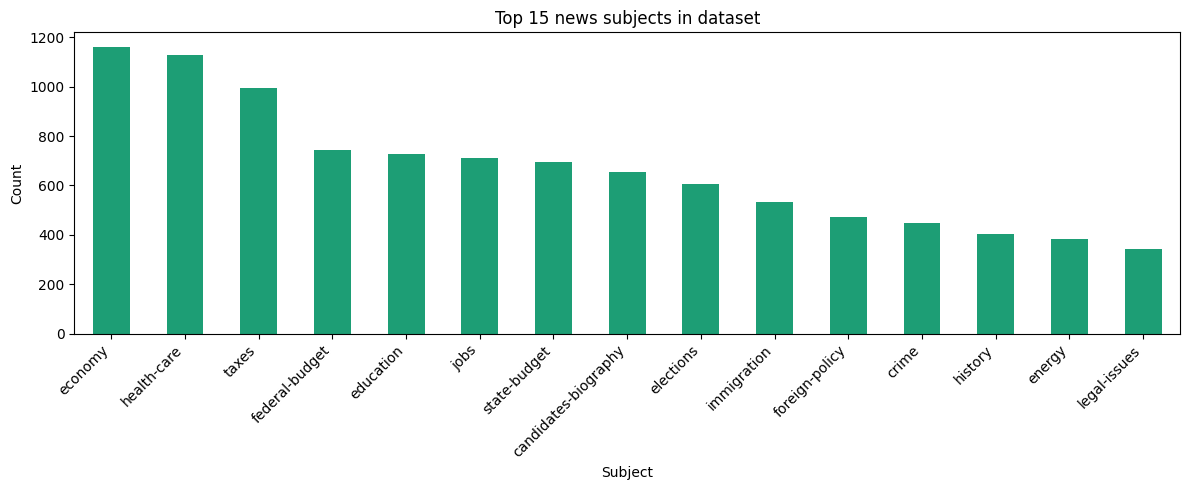

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Split subjects (some rows have multiple subjects separated by comma)
subjects = train_df["subject"].str.split(",").explode().str.strip()

plt.figure(figsize=(12, 5))
subjects.value_counts().head(15).plot(kind="bar", color="#1D9E75")
plt.title("Top 15 news subjects in dataset")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

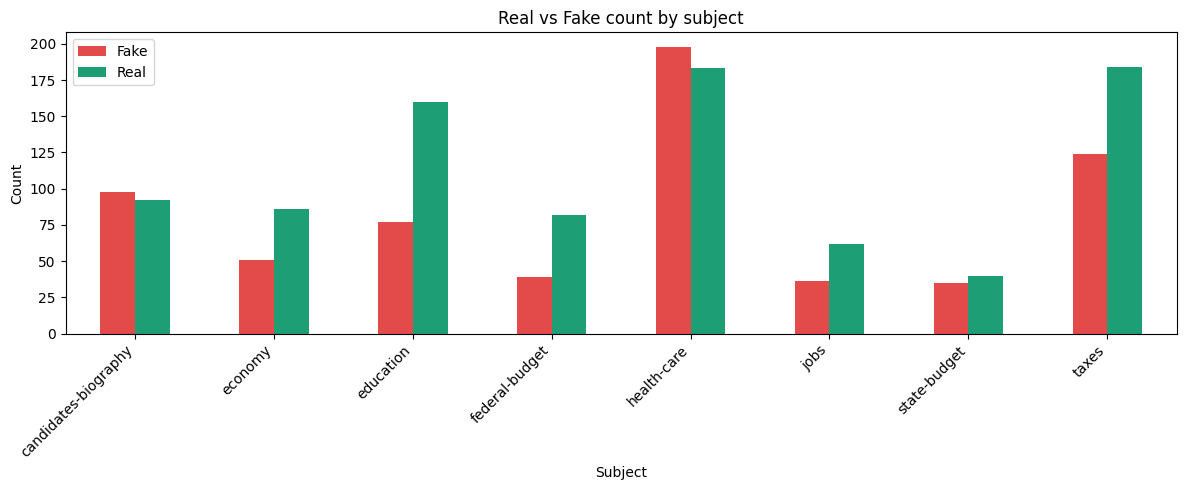

In [35]:
top_subjects = subjects.value_counts().head(8).index.tolist()

subject_label = train_df[["subject", "binary_label"]].copy()
subject_label = subject_label[subject_label["subject"].isin(top_subjects)]

plt.figure(figsize=(12, 5))
subject_counts = subject_label.groupby(["subject", "binary_label"]).size().unstack()
subject_counts.plot(kind="bar", color=["#E24B4A", "#1D9E75"], figsize=(12, 5))
plt.title("Real vs Fake count by subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(["Fake", "Real"])
plt.tight_layout()
plt.show()

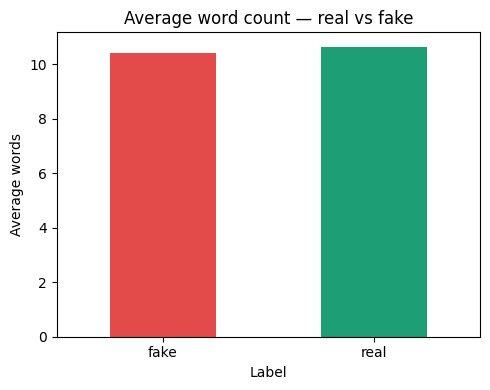

binary_label
fake    10.399064
real    10.641864
Name: word_count, dtype: float64


In [36]:
avg_words = train_df.groupby("binary_label")["word_count"].mean()

plt.figure(figsize=(5, 4))
avg_words.plot(kind="bar", color=["#E24B4A", "#1D9E75"])
plt.title("Average word count — real vs fake")
plt.xlabel("Label")
plt.ylabel("Average words")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(avg_words)

In [37]:
print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"Total train samples : {len(train_df)}")
print(f"Total valid samples : {len(valid_df)}")
print(f"Total test samples  : {len(test_df)}")
print(f"Fake news (train)   : {(train_df['binary_label']=='fake').sum()}")
print(f"Real news (train)   : {(train_df['binary_label']=='real').sum()}")
print(f"Avg word count      : {train_df['word_count'].mean():.1f}")
print(f"Max word count      : {train_df['word_count'].max()}")
print(f"Min word count      : {train_df['word_count'].min()}")
print("=" * 40)

DATASET SUMMARY
Total train samples : 10240
Total valid samples : 1284
Total test samples  : 1267
Fake news (train)   : 4488
Real news (train)   : 5752
Avg word count      : 10.5
Max word count      : 276
Min word count      : 1
